# Neural Network per K-Means Cluster

**Prerequisite:** Run `kmean.ipynb` first — it saves the processed feature matrix, log target, and cluster labels to `cluster_outputs/`.

This notebook loads those artifacts directly and trains a **separate 5-layer neural network** for each cluster.

| Cluster | Learning Rate | Dropout |
|---------|--------------|--------|
| 0 | 1e-3 | 0.2 |
| 1 | 5e-4 | 0.3 |

In [18]:
import sys, warnings, json
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%H:%M:%S',
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print('Libraries imported.')

Libraries imported.


## 1. Load Artifacts from kmean.ipynb

In [19]:
import os
ARTIFACTS = 'cluster_outputs'

required = ['X_features.npy', 'y_log.npy', 'cluster_labels.npy', 'feature_cols.json']
missing  = [f for f in required if not os.path.exists(f'{ARTIFACTS}/{f}')]
if missing:
    raise FileNotFoundError(
        f'Missing artifacts: {missing}\n'
        'Please run kmean.ipynb first to generate them.'
    )

X_full         = np.load(f'{ARTIFACTS}/X_features.npy')
y_log          = np.load(f'{ARTIFACTS}/y_log.npy')          # log1p(copiesSold)
cluster_labels = np.load(f'{ARTIFACTS}/cluster_labels.npy')

with open(f'{ARTIFACTS}/feature_cols.json') as f:
    feature_cols = json.load(f)

N_CLUSTERS = len(np.unique(cluster_labels))

print(f'X_full         : {X_full.shape}')
print(f'y_log          : {y_log.shape}  (mean={y_log.mean():.3f})')
print(f'cluster_labels : {cluster_labels.shape}')
print(f'N_CLUSTERS     : {N_CLUSTERS}')
print(f'feature_cols   : {len(feature_cols)} features')
print()
for i in range(N_CLUSTERS):
    n = (cluster_labels == i).sum()
    print(f'  Cluster {i}: {n:>7,} games  ({100*n/len(cluster_labels):.1f}%)')

X_full         : (80633, 60)
y_log          : (80633,)  (mean=6.411)
cluster_labels : (80633,)
N_CLUSTERS     : 3
feature_cols   : 60 features

  Cluster 0:   7,618 games  (9.4%)
  Cluster 1:  38,243 games  (47.4%)
  Cluster 2:  34,772 games  (43.1%)


## 2. Neural Network Configurations per Cluster

Both clusters use a **5-layer MLP** (`512 → 256 → 128 → 64 → 32 → 1`) — different learning rate and dropout:

In [20]:
from src.models.nn import NeuralNetModel

CLUSTER_NN_CONFIGS = {
    0: dict(
        name='Cluster0_NN',
        hidden_layers=[512, 256, 128, 64, 32],
        lr=5e-4,
        dropout_rate=0.3,
        batch_norm=True,
        batch_size=256,
        max_epochs=150,
        patience=15,
    ),
    1: dict(
        name='Cluster1_NN',
        hidden_layers=[512, 256, 128, 64, 32],
        lr=5e-4,
        dropout_rate=0.3,
        batch_norm=True,
        batch_size=256,
        max_epochs=150,
        patience=15,
    ),
    2: dict(
        name='Cluster1_NN',
        hidden_layers=[512, 256, 128, 64, 32],
        lr=5e-4,
        dropout_rate=0.3,
        batch_norm=True,
        batch_size=256,
        max_epochs=150,
        patience=15,
    ),
}

print(f'  {"Cluster":<10} {"LR":<10} {"Dropout":<10} {"Architecture"}')
print('-' * 65)
for c, cfg in CLUSTER_NN_CONFIGS.items():
    arch = ' → '.join(str(h) for h in cfg['hidden_layers']) + ' → 1'
    print(f'  {c:<10} {cfg["lr"]:<10} {cfg["dropout_rate"]:<10} {arch}')

  Cluster    LR         Dropout    Architecture
-----------------------------------------------------------------
  0          0.0005     0.3        512 → 256 → 128 → 64 → 32 → 1
  1          0.0005     0.3        512 → 256 → 128 → 64 → 32 → 1
  2          0.0005     0.3        512 → 256 → 128 → 64 → 32 → 1


## 3. Train One Neural Network per Cluster

In [21]:
trained_models = {}
cluster_data_splits = {}
results = []

for cluster_id in range(N_CLUSTERS):
    print(f'\n{"="*60}')
    print(f'CLUSTER {cluster_id}')
    print(f'{"="*60}')

    mask = cluster_labels == cluster_id
    X_c  = X_full[mask]
    y_c  = y_log[mask]   # log1p(copiesSold)
    print(f'Samples : {len(X_c):,}')

    # 70 / 15 / 15 split within each cluster
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X_c, y_c, test_size=0.30, random_state=42)
    X_val, X_tst, y_val, y_tst = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=42)

    cluster_data_splits[cluster_id] = {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val':   X_val, 'y_val':   y_val,
        'X_test':  X_tst, 'y_test':  y_tst,
    }
    print(f'Train={len(X_tr):,}  Val={len(X_val):,}  Test={len(X_tst):,}')

    cfg   = CLUSTER_NN_CONFIGS[cluster_id]
    model = NeuralNetModel(**cfg)
    print(f'lr={cfg["lr"]}  dropout={cfg["dropout_rate"]}')

    model.fit(X_tr, y_tr, X_val=X_val, y_val=y_val, verbose=True)

    val_metrics  = model.evaluate(X_val, y_val, split_name='val')
    test_metrics = model.evaluate(X_tst, y_tst, split_name='test')

    trained_models[cluster_id] = model
    results.append({
        'Cluster':      cluster_id,
        'N_train':      len(X_tr),
        'LR':           cfg['lr'],
        'Dropout':      cfg['dropout_rate'],
        'Val_RMSE_log': round(val_metrics['rmse_log'],  4),
        'Val_MAE_log':  round(val_metrics['mae_log'],   4),
        'Val_R2':       round(val_metrics['r2_log'],    4),
        'Val_RMSE_raw': round(val_metrics['rmse_raw'],  0),
        'Val_MAE_raw':  round(val_metrics['mae_raw'],   0),
        'Test_RMSE_log':round(test_metrics['rmse_log'], 4),
        'Test_R2':      round(test_metrics['r2_log'],   4),
        'Test_MAE_raw': round(test_metrics['mae_raw'],  0),
    })

print('\n✓ Both cluster models trained.')


CLUSTER 0
Samples : 7,618
Train=5,332  Val=1,143  Test=1,143
lr=0.0005  dropout=0.3


19:41:19  INFO      [Cluster0_NN] Epoch   10/150  train_loss=14.38768  val_loss=13.75887  (13.8s)
19:41:23  INFO      [Cluster0_NN] Epoch   20/150  train_loss=4.75975  val_loss=3.90699  (17.7s)
19:41:27  INFO      [Cluster0_NN] Epoch   30/150  train_loss=3.77228  val_loss=3.22262  (21.7s)
19:41:31  INFO      [Cluster0_NN] Epoch   40/150  train_loss=3.44092  val_loss=3.16898  (26.2s)
19:41:34  INFO      [Cluster0_NN] Early stopping at epoch 46  (val_loss=3.25149, best=3.13028)
19:41:34  INFO      [Cluster0_NN] Training complete — 46 epochs, 29.2s



CLUSTER 1
Samples : 38,243
Train=26,770  Val=5,736  Test=5,737
lr=0.0005  dropout=0.3


19:42:09  INFO      [Cluster1_NN] Epoch   10/150  train_loss=3.99613  val_loss=2.77197  (34.1s)
19:42:33  INFO      [Cluster1_NN] Epoch   20/150  train_loss=3.52275  val_loss=2.67237  (58.5s)
19:43:12  INFO      [Cluster1_NN] Epoch   30/150  train_loss=3.30819  val_loss=2.65250  (97.5s)
19:44:19  INFO      [Cluster1_NN] Epoch   40/150  train_loss=3.13733  val_loss=2.61378  (165.0s)
19:44:53  INFO      [Cluster1_NN] Epoch   50/150  train_loss=3.04999  val_loss=2.59222  (198.2s)
19:45:41  INFO      [Cluster1_NN] Early stopping at epoch 60  (val_loss=2.60108, best=2.59152)
19:45:41  INFO      [Cluster1_NN] Training complete — 60 epochs, 246.2s



CLUSTER 2
Samples : 34,772
Train=24,340  Val=5,216  Test=5,216
lr=0.0005  dropout=0.3


19:46:59  INFO      [Cluster1_NN] Epoch   10/150  train_loss=4.17575  val_loss=3.21551  (77.4s)
19:48:35  INFO      [Cluster1_NN] Epoch   20/150  train_loss=3.75818  val_loss=3.10266  (173.7s)
19:49:48  INFO      [Cluster1_NN] Epoch   30/150  train_loss=3.55162  val_loss=3.07146  (246.5s)
19:50:30  INFO      [Cluster1_NN] Epoch   40/150  train_loss=3.37597  val_loss=3.04636  (289.1s)
19:51:15  INFO      [Cluster1_NN] Epoch   50/150  train_loss=3.25479  val_loss=3.00012  (333.4s)
19:51:45  INFO      [Cluster1_NN] Early stopping at epoch 56  (val_loss=3.01626, best=2.99067)
19:51:45  INFO      [Cluster1_NN] Training complete — 56 epochs, 364.1s



✓ Both cluster models trained.


## 4. Results Comparison Table

In [22]:
results_df = pd.DataFrame(results).set_index('Cluster')
print('Per-Cluster Neural Network Performance:')
print('=' * 65)
display(results_df.style
    .background_gradient(cmap='RdYlGn_r', subset=['Val_RMSE_log', 'Test_RMSE_log'])
    .background_gradient(cmap='RdYlGn',   subset=['Val_R2', 'Test_R2'])
    .format({
        'Val_RMSE_log':  '{:.4f}',
        'Val_MAE_log':   '{:.4f}',
        'Val_R2':        '{:.4f}',
        'Val_RMSE_raw':  '{:,.0f}',
        'Val_MAE_raw':   '{:,.0f}',
        'Test_RMSE_log': '{:.4f}',
        'Test_R2':       '{:.4f}',
        'Test_MAE_raw':  '{:,.0f}',
        'LR':            '{:.0e}',
    })
)

Per-Cluster Neural Network Performance:


,N_train,LR,Dropout,Val_RMSE_log,Val_MAE_log,Val_R2,Val_RMSE_raw,Val_MAE_raw,Test_RMSE_log,Test_R2,Test_MAE_raw
Cluster,,,,,,,,,,,
0,5332,5e-04,0.300000,1.7693,1.3933,0.6452,"709,062","52,027",1.9023,0.6235,"46,853"
1,26770,5e-04,0.300000,1.6098,1.2442,0.7152,"961,196","92,326",1.6037,0.7126,"95,380"
2,24340,5e-04,0.300000,1.7294,1.3600,0.6445,"231,477","16,516",1.7719,0.6255,"13,379"


## 5. Training Loss Curves per Cluster

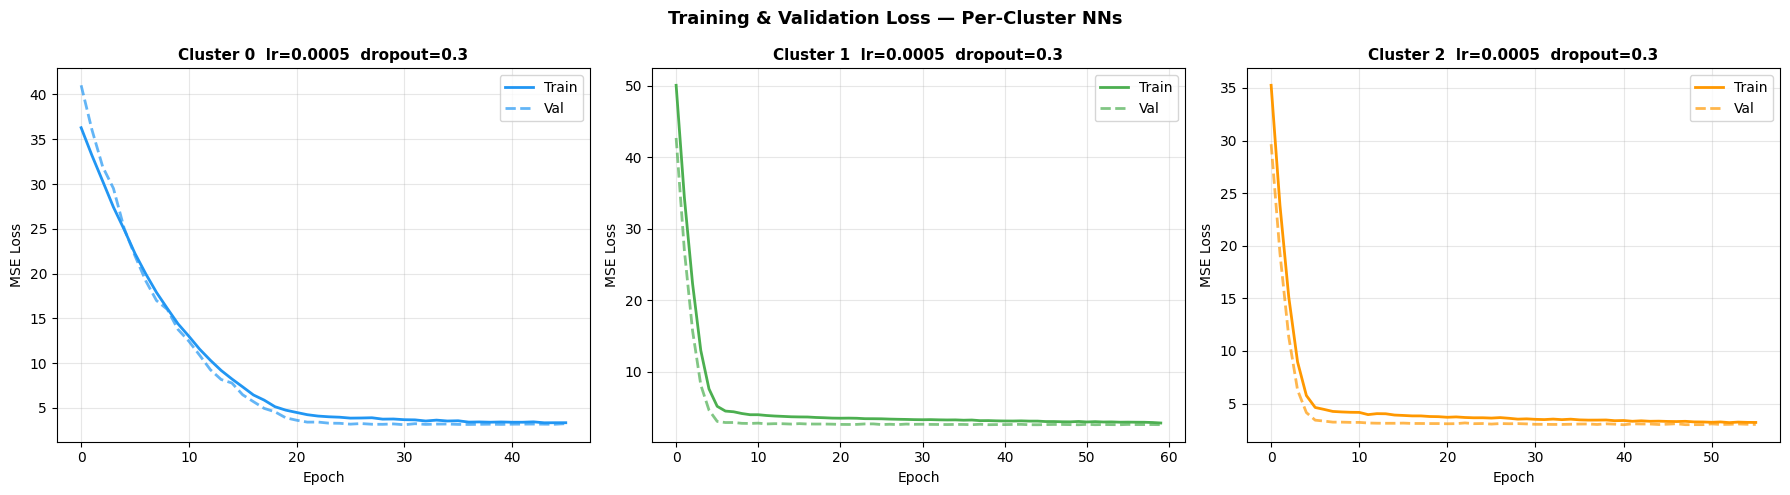

In [26]:
colors = ['#2196F3', '#4CAF50', '#FF9800']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cluster_id, model in trained_models.items():
    ax  = axes[cluster_id]
    cfg = CLUSTER_NN_CONFIGS[cluster_id]
    ax.plot(model.history.get('train_loss', []), color=colors[cluster_id],
            linewidth=2, label='Train')
    if model.history.get('val_loss'):
        ax.plot(model.history['val_loss'], color=colors[cluster_id],
                linewidth=2, linestyle='--', alpha=0.7, label='Val')
    ax.set_title(f'Cluster {cluster_id}  lr={cfg["lr"]}  dropout={cfg["dropout_rate"]}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('Training & Validation Loss — Per-Cluster NNs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Predicted vs Actual per Cluster

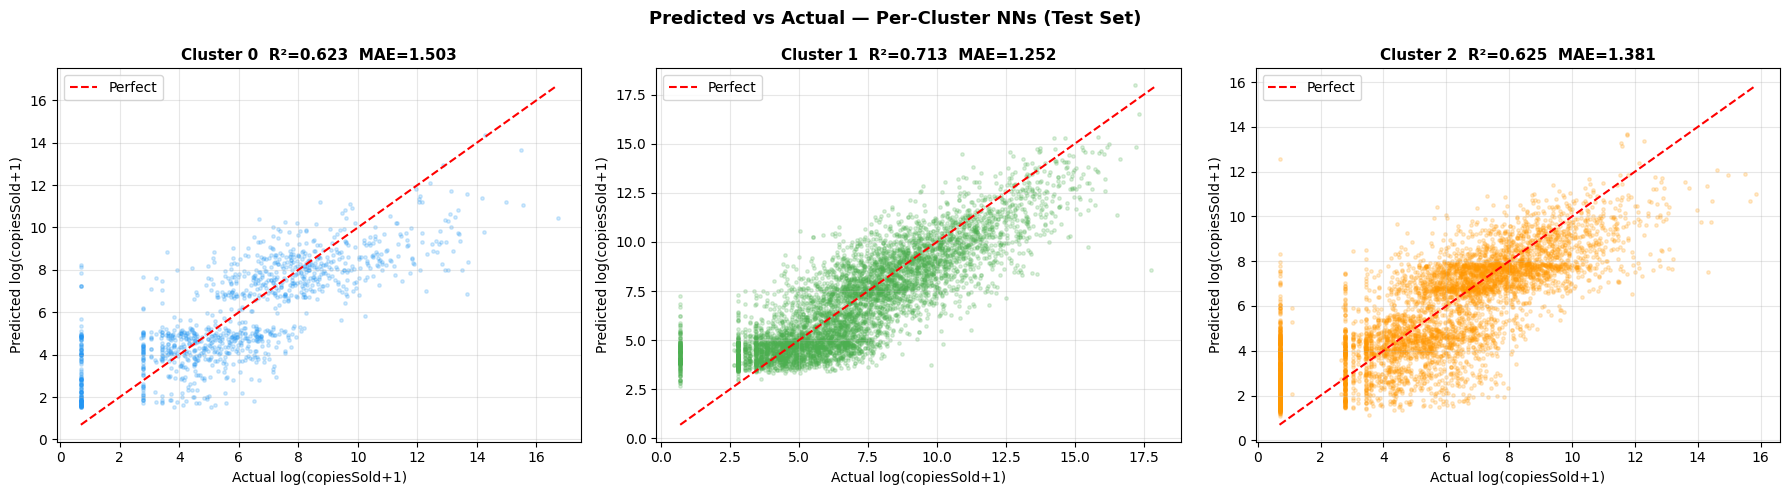

In [27]:
colors = ['#2196F3', '#4CAF50', '#FF9800']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cluster_id, model in trained_models.items():
    ax     = axes[cluster_id]
    splits = cluster_data_splits[cluster_id]
    y_true = splits['y_test']
    y_pred = model.predict(splits['X_test'])

    ax.scatter(y_true, y_pred, alpha=0.2, s=6, color=colors[cluster_id])
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
    ax.set_xlabel('Actual log(copiesSold+1)')
    ax.set_ylabel('Predicted log(copiesSold+1)')
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_title(f'Cluster {cluster_id}  R²={r2:.3f}  MAE={mae:.3f}',
                 fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('Predicted vs Actual — Per-Cluster NNs (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

# ── Per-cluster metrics ────────────────────────────────────────────────────────
rows = []
all_train_true, all_train_pred = [], []
all_val_true,   all_val_pred   = [], []
all_test_true,  all_test_pred  = [], []

for cluster_id, model in trained_models.items():
    splits = cluster_data_splits[cluster_id]

    y_train_pred = model.predict(splits['X_train'])
    y_val_pred   = model.predict(splits['X_val'])
    y_test_pred  = model.predict(splits['X_test'])

    train_rmse = float(np.sqrt(mean_squared_error(splits['y_train'], y_train_pred)))
    val_rmse   = float(np.sqrt(mean_squared_error(splits['y_val'],   y_val_pred)))
    test_rmse  = float(np.sqrt(mean_squared_error(splits['y_test'],  y_test_pred)))
    val_r2     = float(r2_score(splits['y_val'],  y_val_pred))
    test_r2    = float(r2_score(splits['y_test'], y_test_pred))

    rows.append({
        'Segment':        f'Cluster {cluster_id}',
        'Train_RMSE_log': round(train_rmse, 4),
        'Val_RMSE_log':   round(val_rmse,   4),
        'Test_RMSE_log':  round(test_rmse,  4),
        'Val_R2_log':     round(val_r2,     4),
        'Test_R2_log':    round(test_r2,    4),
    })

    all_train_true.append(splits['y_train']);  all_train_pred.append(y_train_pred)
    all_val_true.append(splits['y_val']);      all_val_pred.append(y_val_pred)
    all_test_true.append(splits['y_test']);    all_test_pred.append(y_test_pred)

# ── Combined (all clusters pooled) ────────────────────────────────────────────
cat = lambda lst: np.concatenate(lst)

rows.append({
    'Segment':        'All Clusters (combined)',
    'Train_RMSE_log': round(float(np.sqrt(mean_squared_error(cat(all_train_true), cat(all_train_pred)))), 4),
    'Val_RMSE_log':   round(float(np.sqrt(mean_squared_error(cat(all_val_true),   cat(all_val_pred)))),   4),
    'Test_RMSE_log':  round(float(np.sqrt(mean_squared_error(cat(all_test_true),  cat(all_test_pred)))),  4),
    'Val_R2_log':     round(float(r2_score(cat(all_val_true),  cat(all_val_pred))),  4),
    'Test_R2_log':    round(float(r2_score(cat(all_test_true), cat(all_test_pred))), 4),
})

# ── Display ────────────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame(rows).set_index('Segment')
display(metrics_df.style
    .background_gradient(cmap='RdYlGn_r', subset=['Train_RMSE_log', 'Val_RMSE_log', 'Test_RMSE_log'])
    .background_gradient(cmap='RdYlGn',   subset=['Val_R2_log', 'Test_R2_log'])
    .format('{:.4f}')
)

,Train_RMSE_log,Val_RMSE_log,Test_RMSE_log,Val_R2_log,Test_R2_log
Segment,,,,,
Cluster 0,1.5441,1.7693,1.9023,0.6452,0.6235
Cluster 1,1.4418,1.6098,1.6037,0.7152,0.7126
Cluster 2,1.5774,1.7294,1.7719,0.6445,0.6255
All Clusters (combined),1.5114,1.6777,1.7075,0.6934,0.6812


## 7. Export Predictions to CSV

In [28]:
import os
os.makedirs('cluster_outputs', exist_ok=True)

all_preds = []
for cluster_id, model in trained_models.items():
    mask   = cluster_labels == cluster_id
    X_c    = X_full[mask]
    y_c    = y_log[mask]
    y_pred = model.predict(X_c)

    pred_df = pd.DataFrame({
        'cluster':             cluster_id,
        'actual_log':          y_c,
        'predicted_log':       y_pred,
        'actual_copies':       np.expm1(y_c),
        'predicted_copies':    np.expm1(y_pred),
        'residual_log':        y_pred - y_c,
    })
    path = f'cluster_outputs/cluster_{cluster_id}_nn_predictions.csv'
    pred_df.to_csv(path, index=False)
    all_preds.append(pred_df)
    print(f'Cluster {cluster_id} → {path}  ({len(pred_df):,} rows)')

combined = pd.concat(all_preds, ignore_index=True)
combined.to_csv('cluster_outputs/all_clusters_nn_predictions.csv', index=False)
print(f'\nCombined → cluster_outputs/all_clusters_nn_predictions.csv  ({len(combined):,} rows)')

Cluster 0 → cluster_outputs/cluster_0_nn_predictions.csv  (7,618 rows)
Cluster 1 → cluster_outputs/cluster_1_nn_predictions.csv  (38,243 rows)
Cluster 2 → cluster_outputs/cluster_2_nn_predictions.csv  (34,772 rows)

Combined → cluster_outputs/all_clusters_nn_predictions.csv  (80,633 rows)


In [30]:
import os
os.makedirs('cluster_outputs', exist_ok=True)

test_pred_rows = []
for cluster_id, model in trained_models.items():
    splits = cluster_data_splits[cluster_id]
    y_true = splits['y_test']
    y_pred = model.predict(splits['X_test'])

    for i in range(len(y_true)):
        test_pred_rows.append({
            'cluster':          cluster_id,
            'actual_log':       float(y_true[i]),
            'predicted_log':    float(y_pred[i]),
            'actual_copies':    float(np.expm1(y_true[i])),
            'predicted_copies': float(np.expm1(y_pred[i])),
            'residual_log':     float(y_pred[i] - y_true[i]),
        })

test_pred_df = pd.DataFrame(test_pred_rows)
test_pred_df.to_csv('cluster_outputs/test_set_predictions_all_clusters.csv', index=False)
print(f'Saved → cluster_outputs/test_set_predictions_all_clusters.csv  ({len(test_pred_df):,} rows)')
display(test_pred_df.head(6))

Saved → cluster_outputs/test_set_predictions_all_clusters.csv  (12,096 rows)


,cluster,actual_log,predicted_log,actual_copies,predicted_copies,residual_log
0,0,8.847216,7.961727,6953.997070,2868.022461,-0.885489
1,0,9.809232,10.917000,18199.998047,55104.226562,1.107768
2,0,7.214504,8.387708,1357.999756,4391.736816,1.173203
3,0,3.555348,4.134030,34.000004,61.429028,0.578682
4,0,3.433987,7.478391,29.999998,1768.391846,4.044404
5,0,2.772589,5.039697,15.000000,153.423248,2.267108


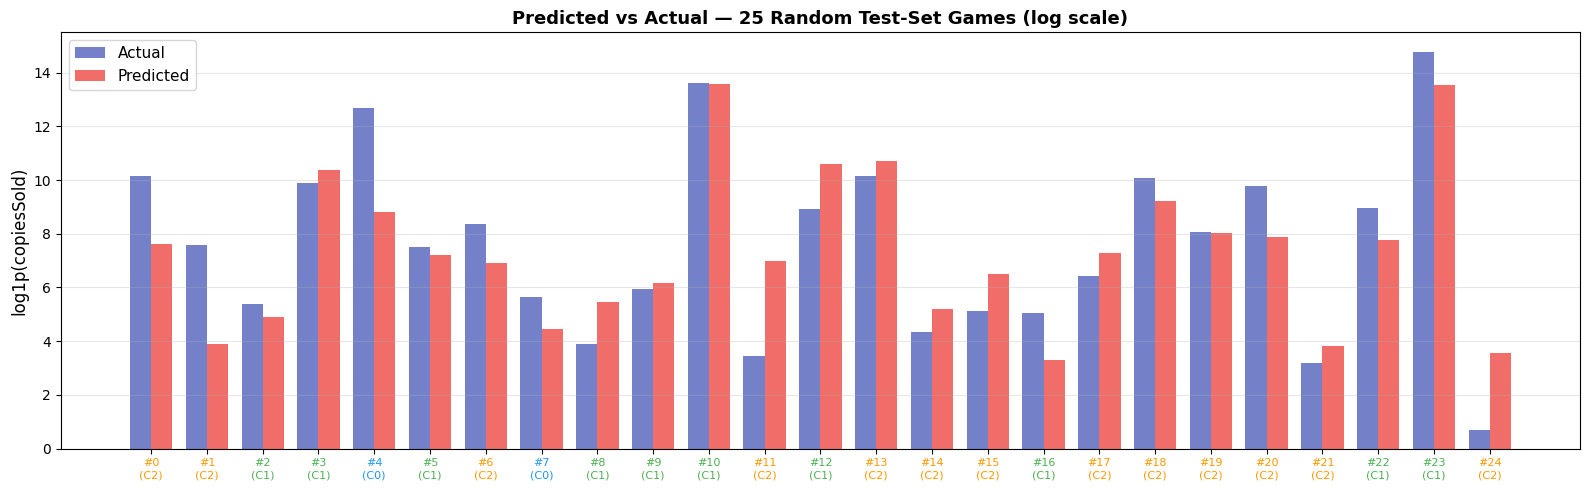

,cluster,Actual_log,Predicted_log,Residual_log
0,2,10.164,7.636,-2.528
1,2,7.594,3.889,-3.705
2,1,5.403,4.889,-0.514
3,1,9.897,10.365,0.468
4,0,12.666,8.822,-3.844
5,1,7.525,7.220,-0.305
6,2,8.374,6.903,-1.471
7,0,5.656,4.459,-1.197
8,1,3.892,5.445,1.553
9,1,5.945,6.152,0.207


In [38]:
sample25 = test_pred_df.sample(n=25, random_state=41211).reset_index(drop=True)

x     = np.arange(25)
width = 0.38

cluster_colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width/2, sample25['actual_log'],    width, label='Actual',    color='#5C6BC0', alpha=0.85)
ax.bar(x + width/2, sample25['predicted_log'], width, label='Predicted', color='#EF5350', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(
    [f'#{i}\n(C{int(sample25.loc[i, "cluster"])})' for i in range(25)],
    fontsize=8,
)

# Colour each x-tick label by its cluster
for tick, cid in zip(ax.get_xticklabels(), sample25['cluster']):
    tick.set_color(cluster_colors[int(cid)])

ax.set_ylabel('log1p(copiesSold)', fontsize=12)
ax.set_title('Predicted vs Actual — 25 Random Test-Set Games (log scale)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(sample25[['cluster', 'actual_log', 'predicted_log', 'residual_log']]
    .rename(columns={'actual_log': 'Actual_log', 'predicted_log': 'Predicted_log', 'residual_log': 'Residual_log'})
    .style.format({'Actual_log': '{:.3f}', 'Predicted_log': '{:.3f}', 'Residual_log': '{:.3f}'})
    .background_gradient(cmap='RdYlGn_r', subset=['Residual_log'])
)

In [35]:
from sklearn.metrics import mean_squared_error

# Per-cluster test RMSE (log scale)
print(f'{"Cluster":<10} {"N_test":<10} {"RMSE_log":<12}')
print('-' * 35)

total_y_true, total_y_pred = [], []
for cluster_id, model in trained_models.items():
    splits = cluster_data_splits[cluster_id]
    y_true = splits['y_test']
    y_pred = model.predict(splits['X_test'])

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    print(f'{cluster_id:<10} {len(y_true):<10,} {rmse:<12.4f}')

    total_y_true.append(y_true)
    total_y_pred.append(y_pred)

# Average across all clusters (weighted by test set size)
all_true = np.concatenate(total_y_true)
all_pred = np.concatenate(total_y_pred)
avg_rmse = float(np.sqrt(mean_squared_error(all_true, all_pred)))

print('-' * 35)
print(f'{"Overall":<10} {len(all_true):<10,} {avg_rmse:<12.4f}')

Cluster    N_test     RMSE_log    
-----------------------------------
0          1,143      1.9023      
1          5,737      1.6037      
2          5,216      1.7719      
-----------------------------------
Overall    12,096     1.7075      
